# 02 — Feature Engineering

This notebook explains how features were built for the ML models — RFM calculation, correlation analysis, and feature importance.

## Setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from config import PG_URL
engine = create_engine(PG_URL)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_palette('Blues_d')
print("✅ Setup complete")


✅ Setup complete


## 1. RFM Feature Engineering

RFM stands for **Recency**, **Frequency**, **Monetary** — the three most important customer behavior signals.

In [2]:

sql = '''
SELECT
    f.customer_id,
    DATE '2018-09-01' - MAX(f.order_date)::date   AS recency_days,
    COUNT(DISTINCT f.order_id)                    AS frequency,
    ROUND(SUM(f.revenue)::numeric, 2)             AS monetary,
    ROUND(AVG(f.review_score)::numeric, 2)        AS avg_review_score,
    SUM(CASE WHEN f.delivery_delay_days > 0
             THEN 1 ELSE 0 END)                   AS late_deliveries,
    COUNT(DISTINCT f.category)                    AS unique_categories
FROM olist.fact_orders f
WHERE f.is_delivered = 1
GROUP BY f.customer_id
'''
with engine.connect() as conn:
    df = pd.read_sql(text(sql), conn)

print(f"Total customers: {len(df):,}")
df.describe().round(2)


Total customers: 96,478


,recency_days,frequency,monetary,avg_review_score,late_deliveries,unique_categories
count,96478.00,96478.0,96478.00,96478.00,96478.00,96478.00
mean,242.66,1.0,159.83,4.16,0.08,0.99
std,152.84,0.0,218.79,1.28,0.31,0.15
min,3.00,1.0,9.59,1.00,0.00,0.00
25%,119.00,1.0,61.85,4.00,0.00,1.00
50%,224.00,1.0,105.28,5.00,0.00,1.00
75%,352.00,1.0,176.26,5.00,0.00,1.00
max,716.00,1.0,13664.08,5.00,21.00,3.00


## 2. RFM Distributions

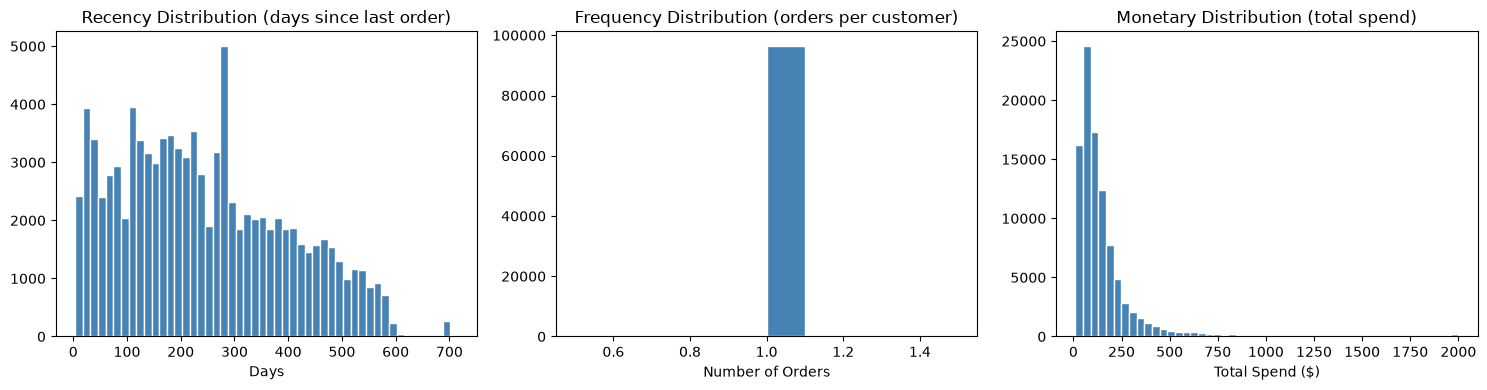

In [3]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['recency_days'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution (days since last order)')
axes[0].set_xlabel('Days')
axes[1].hist(df['frequency'].clip(upper=10), bins=10, color='steelblue', edgecolor='white')
axes[1].set_title('Frequency Distribution (orders per customer)')
axes[1].set_xlabel('Number of Orders')
axes[2].hist(df['monetary'].clip(upper=2000), bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Monetary Distribution (total spend)')
axes[2].set_xlabel('Total Spend ($)')
plt.tight_layout()
plt.show()


## 3. Churn Label Creation

Churn Distribution:
  Active  (0): 38,196  (39.6%)
  Churned (1): 58,282  (60.4%)


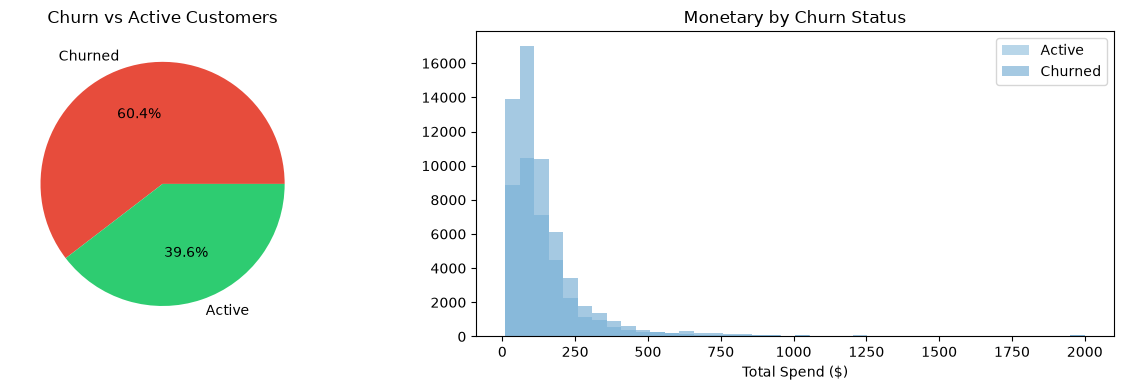

In [4]:

df['churned'] = (df['recency_days'] > 180).astype(int)

print("Churn Distribution:")
print(f"  Active  (0): {(df['churned']==0).sum():,}  ({(df['churned']==0).mean()*100:.1f}%)")
print(f"  Churned (1): {df['churned'].sum():,}  ({df['churned'].mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].pie([df['churned'].sum(), (df['churned']==0).sum()],
            labels=['Churned','Active'], autopct='%1.1f%%',
            colors=['#e74c3c','#2ecc71'])
axes[0].set_title('Churn vs Active Customers')

for label, grp in df.groupby('churned'):
    axes[1].hist(grp['monetary'].clip(upper=2000), bins=40,
                 alpha=0.6, label='Churned' if label else 'Active')
axes[1].set_title('Monetary by Churn Status')
axes[1].set_xlabel('Total Spend ($)')
axes[1].legend()
plt.tight_layout()
plt.show()


## 4. Correlation Heatmap

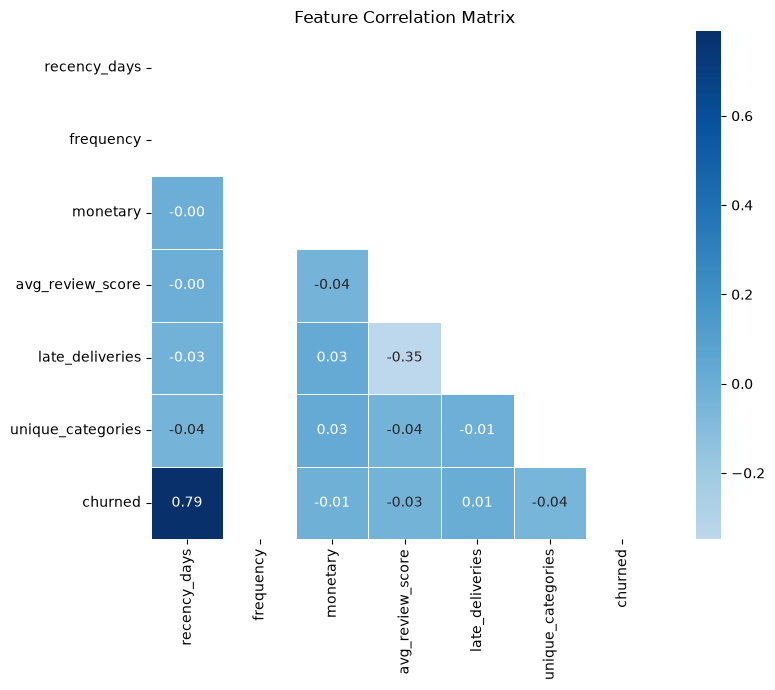

In [5]:

features = ['recency_days','frequency','monetary','avg_review_score',
            'late_deliveries','unique_categories','churned']
corr = df[features].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 5. RFM Segmentation

           customers  avg_spend  avg_recency
segment                                     
Champions       7876     311.37        93.72
Loyal          33097     208.83       179.06
Potential      39828     127.01       272.53
At Risk        12606      67.77       359.90
Lost            3071      46.61       441.38


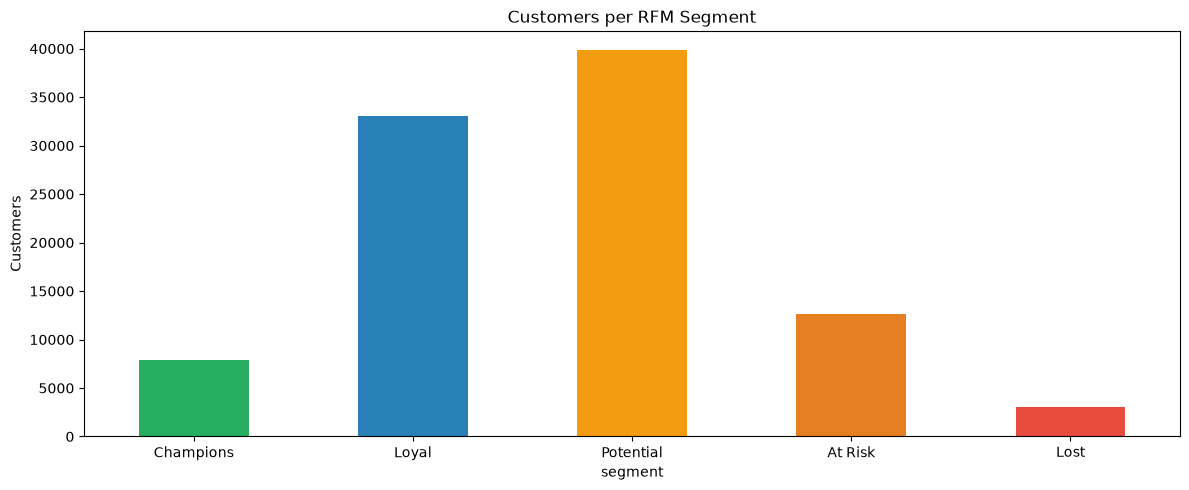

In [6]:

df['r_score'] = pd.qcut(df['recency_days'],  5, labels=[5,4,3,2,1]).astype(int)
df['f_score'] = pd.qcut(df['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
df['m_score'] = pd.qcut(df['monetary'].rank(method='first'),  5, labels=[1,2,3,4,5]).astype(int)
df['rfm']     = df['r_score'] + df['f_score'] + df['m_score']

def segment(s):
    if s >= 13: return 'Champions'
    if s >= 10: return 'Loyal'
    if s >= 7:  return 'Potential'
    if s >= 5:  return 'At Risk'
    return 'Lost'

df['segment'] = df['rfm'].apply(segment)
summary = df.groupby('segment').agg(
    customers=('customer_id','count'),
    avg_spend=('monetary','mean'),
    avg_recency=('recency_days','mean')
).round(2).sort_values('avg_spend', ascending=False)

print(summary.to_string())
colors = {'Champions':'#27ae60','Loyal':'#2980b9','Potential':'#f39c12','At Risk':'#e67e22','Lost':'#e74c3c'}
summary['customers'].plot(kind='bar', color=[colors[s] for s in summary.index])
plt.title('Customers per RFM Segment')
plt.ylabel('Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
